# G09 [C II] — visibility-domain forward mass modeling

実観測 G09 の pre-imaging 複素 visibility を、disk + Hernquist bulge + NFW halo、SIE + external shear/convergence lens、3D rotating tracer の forward model で直接 fit する。

- 入力 Measurement Set の作成・`statwt`・偏波平均・NPZ export は `../G09_process_vis.ipynb` が担当する。
- この notebook は `../sim_imaging/G09.processed_uv_CII.all.npz` を読み、dirty image pixel を fit せず visibility の実部・虚部へ Gaussian likelihood を適用する。
- lens center は HST Gaussian centroid に固定し、それ以外の source/lens/mass parameter は `G09_stage4.toml` の free-parameter list で制御する。
- `bulge` と `no_bulge` で共通 parameter を揃え、Dynesty evidence を比較する。
- 2 model fit を process 並列化し、各fit内では8 Dynesty threadが専用の `UVContext` / FINUFFT planを使う。

最初は `G09_BENCHMARK_ONLY=1` で実行時間と入力を確認すること。full sampling は長時間実行になる。

In [1]:
import os

# 独立な bulge/no-bulge fit を process 並列化するため、各 process 内の BLAS threading は止める。
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

from dataclasses import replace
from pathlib import Path
import hashlib
import json
import multiprocessing as mp
from multiprocessing.pool import ThreadPool
from queue import SimpleQueue
from threading import local
import pickle
import time
import tomllib

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from cmcrameri import cm
from dynesty import plotting as dyplot

%matplotlib inline

CWD = Path.cwd().resolve()
if CWD.name == 'forward_mass' and CWD.parent.name == 'examples':
    WORKFLOW_DIR = CWD
    EXAMPLES_DIR = CWD.parent
elif CWD.name == 'examples':
    WORKFLOW_DIR = CWD / 'forward_mass'
    EXAMPLES_DIR = CWD
else:
    raise FileNotFoundError('Run this notebook from examples/forward_mass or examples.')

from glint import lensing
from glint.context import UVContext, build_finufft_plans, build_uv_layout
from glint.cosmology import critical_density, kpc_per_arcsec
from glint.forward import cube_to_visibilities, forward_model_3D_mass_intrinsic, mass_rotation_curve
from glint.inference import run_dynamic_dynesty
from glint.interferometer import (
    load_processed_uv, primary_beam, vis_to_image_finufft_type3,
)
from glint.mass_model import r200_kpc_from_m200

## Configuration and input provenance

`G09_process_vis.ipynb` は3つの continuum-subtracted MS を同じ velocity grid へ変換し、line-free channel で `statwt` を行った後、line channel だけを combined NPZ に保存する。このため本 notebook では NPZ 内の `sigma=1/sqrt(weight)` を使い、line-free MAD による再 scale は行わない。

In [2]:
CONFIG_PATH = WORKFLOW_DIR / 'G09_stage5.toml'
with CONFIG_PATH.open('rb') as handle:
    CONFIG = tomllib.load(handle)

def resolve_workflow_path(value):
    return (WORKFLOW_DIR / value).resolve()

data_cfg = CONFIG['data']
NUFFT_TYPE = int(data_cfg.get('nufft_type', 3))
target_cfg = CONFIG['target']
image_grid_cfg = CONFIG['grid']['image']
source_grid_cfg = CONFIG['grid']['source']
radial_cfg = CONFIG['radial_profile']
model_cfg = CONFIG['model']
fit_cfg = CONFIG['fit']
dynesty_cfg = CONFIG['dynesty']
parallel_cfg = CONFIG['parallel']

UV_ARCHIVE = resolve_workflow_path(data_cfg['processed_uv_archive'])
PROCESSED_MS_PATHS = tuple(resolve_workflow_path(p) for p in data_cfg['processed_measurement_sets'])
RAW_MS_PATHS = tuple(resolve_workflow_path(p) for p in data_cfg['raw_measurement_sets'])

print('Raw continuum-subtracted Measurement Sets:')
for path in RAW_MS_PATHS:
    print(f'  {path}  exists={path.is_dir()}')
print('Processed/regridded Measurement Sets:')
for path in PROCESSED_MS_PATHS:
    print(f'  {path}  exists={path.is_dir()}')
print(f'Fit archive: {UV_ARCHIVE}  exists={UV_ARCHIVE.is_file()}')

if not UV_ARCHIVE.is_file():
    raise FileNotFoundError(
        f'Missing {UV_ARCHIVE}. Run G09_process_vis.ipynb in the CASA environment '
        'through its final NPZ-export cell, then run this notebook in jaxlens.'
    )
missing_processed = [str(path) for path in PROCESSED_MS_PATHS if not path.is_dir()]
if missing_processed:
    raise FileNotFoundError(f'Missing processed Measurement Sets: {missing_processed}')

OUTPUT_DIR = WORKFLOW_DIR / 'output' / 'G09_uv' / 'results'
CACHE_DIR = OUTPUT_DIR / 'cache'
FIGURE_DIR = OUTPUT_DIR / 'figures'
for directory in (CACHE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

Raw continuum-subtracted Measurement Sets:
  /lwk/atsujita/G09/data/ALMA/Band6/combined/MS/Band6.tsujita.ms.contsub  exists=True
  /lwk/atsujita/G09/data/ALMA/Band6/combined/MS/Band6.tadaki.ms.contsub  exists=True
  /lwk/atsujita/G09/data/ALMA/Band6/combined/MS/Band6.riechers.ms.contsub  exists=True
Processed/regridded Measurement Sets:
  /lwk/atsujita/HATLASJ0900/glint/examples/data/MS/Band6.tsujita.ms.contsub.tbin.chbin  exists=True
  /lwk/atsujita/HATLASJ0900/glint/examples/data/MS/Band6.tadaki.ms.contsub.tbin.chbin  exists=True
  /lwk/atsujita/HATLASJ0900/glint/examples/data/MS/Band6.riechers.ms.contsub.tbin.chbin  exists=True
Fit archive: /lwk/atsujita/HATLASJ0900/glint/examples/sim_imaging/G09.processed_uv_CII.all.npz  exists=True


## Visibility data, grids, and cached FINUFFT operator

MS/NPZ の phase center を image-plane origin とする。`max_angular_scale_arcsec=4` より大きな angular scale に対応する短基線を除き、各 channel の uv layout と FINUFFT plan を一度だけ構築する。

In [3]:
SOURCE_REDSHIFT = float(target_cfg['redshift'])
KPC_PER_ARCSEC = kpc_per_arcsec(SOURCE_REDSHIFT)
RHO_CRITICAL_MSUN_KPC3 = critical_density(SOURCE_REDSHIFT)
HALO_CONCENTRATION_200 = float(model_cfg['halo_concentration_200'])

XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC = lensing.make_grid_arcsec(
    source_grid_cfg['grid_size'], source_grid_cfg['grid_size'],
    source_grid_cfg['pixel_size_arcsec'],
    source_grid_cfg['x_center_arcsec'], source_grid_cfg['y_center_arcsec'],
)
XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC = lensing.make_grid_arcsec(
    image_grid_cfg['grid_size'], image_grid_cfg['grid_size'],
    image_grid_cfg['pixel_size_arcsec'],
    image_grid_cfg['x_center_arcsec'], image_grid_cfg['y_center_arcsec'],
)

RADIUS_MAX_KPC = float(radial_cfg['radius_max_kpc'])
RADIAL_STEP_ARCSEC = float(radial_cfg['radial_step_arcsec'])
RADIAL_INTERVALS = int(np.ceil((RADIUS_MAX_KPC / KPC_PER_ARCSEC) / RADIAL_STEP_ARCSEC))
RADIUS_ARCSEC = np.arange(RADIAL_INTERVALS + 1) * RADIAL_STEP_ARCSEC
RADIUS_KPC = RADIUS_ARCSEC * KPC_PER_ARCSEC

def limited_flags(flag, maximum):
    if maximum <= 0:
        return np.asarray(flag, dtype=bool).copy()
    result = np.ones_like(flag, dtype=bool)
    for channel in range(flag.shape[0]):
        valid = np.flatnonzero(~flag[channel])
        if valid.size > maximum:
            valid = valid[np.linspace(0, valid.size - 1, maximum, dtype=int)]
        result[channel, valid] = False
    return result

def flatten_selected(array, flag, slices):
    output = np.empty(sum(np.count_nonzero(~row) for row in flag), dtype=array.dtype)
    for channel, output_slice in enumerate(slices):
        if output_slice is not None:
            output[output_slice] = array[channel, ~flag[channel]]
    return output

def build_observation():
    uv = load_processed_uv(UV_ARCHIVE)
    order = np.argsort(uv.v_kms)
    if not np.array_equal(order, np.arange(uv.nchan)):
        pb_fwhm = uv.pb_fwhm_as if uv.pb_fwhm_as.ndim == 0 else uv.pb_fwhm_as[order]
        uv = replace(
            uv, uvw_lam=uv.uvw_lam[:, order], data=uv.data[order],
            sigma=uv.sigma[order], flag=uv.flag[order],
            freqs_hz=uv.freqs_hz[order], v_kms=uv.v_kms[order],
            pb_fwhm_as=pb_fwhm,
        )
    if not np.all(np.diff(uv.v_kms) > 0):
        raise ValueError('Velocity channels must be unique after sorting.')
    flag = uv.flags_with_max_angular_scale_cut(float(data_cfg['max_angular_scale_arcsec']))
    flag = limited_flags(flag, int(data_cfg['max_visibilities_per_channel']))
    k_list, slices, ntotal = build_uv_layout(uv.uvw_lam[0], uv.uvw_lam[1], flag)
    plans = build_finufft_plans(
        k_list, nufft_type=NUFFT_TYPE,
        image_shape=XX_IMAGE_ARCSEC.shape,
        pixsize_arcsec=float(image_grid_cfg['pixel_size_arcsec']),
        eps=float(data_cfg['finufft_tolerance']),
    )
    pb = primary_beam(XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC, uv.pb_fwhm_as)
    context = UVContext(
        pb=pb, plans=plans, slices=slices, nchan=uv.nchan,
        Ntot=ntotal, flag=flag, nufft_type=NUFFT_TYPE,
    )
    return {
        'uv': uv, 'flag': flag, 'slices': slices, 'uv_context': context,
        'data': flatten_selected(uv.data, flag, slices),
        'sigma': flatten_selected(uv.sigma, flag, slices),
    }

OBSERVATION = build_observation()
UV_DATA = OBSERVATION['uv']
VELOCITY_CHANNELS_KMS = UV_DATA.v_kms
SPECTRAL_RESOLUTION_SIGMA_KMS = UV_DATA.spec_res_sigma_kms

print(f'phase center (RA, Dec) = {UV_DATA.phase_center_deg} deg')
print(f'velocity channels = {VELOCITY_CHANNELS_KMS} km/s')
print(f'spectral sigma = {SPECTRAL_RESOLUTION_SIGMA_KMS:.2f} km/s')
print(f'visibility rows/channel before cuts = {UV_DATA.data.shape[1]:,}')
print(f'unflagged channel-visibilities = {OBSERVATION["uv_context"].Ntot:,}')
print(f'median exported sigma = {np.median(OBSERVATION["sigma"]):.5g} Jy')
print(f'image grid = {XX_IMAGE_ARCSEC.shape}, source grid = {XX_SOURCE_ARCSEC.shape}')

phase center (RA, Dec) = [135.19097083   0.68977778] deg
velocity channels = [-325. -275. -225. -175. -125.  -75.  -25.   25.   75.  125.  175.  225.
  275.  325.] km/s
spectral sigma = 21.23 km/s
visibility rows/channel before cuts = 18,651
unflagged channel-visibilities = 242,772
median exported sigma = 0.014849 Jy
image grid = (200, 200), source grid = (200, 200)


## Physical forward model and priors

`baseline` は mock truth ではなく、既存 G09 moment-0 fit と HST centroid に基づく参照値である。free list にない値だけが baseline に固定される。`no_bulge` では `B/T=0`、`bulge` では TOML の一様 prior を使う。

In [4]:
MASS_PARAMETER_NAMES = (
    'log10_m_baryon', 'disk_scale_radius_kpc', 'log10_m200',
    'bulge_to_total', 'bulge_effective_radius_kpc',
)
SOURCE_PARAMETER_NAMES = (
    'source_x_arcsec', 'source_y_arcsec', 'flux_normalization',
    'inclination_deg', 'position_angle_deg', 'surface_brightness_scale_arcsec',
    'velocity_dispersion_center_kms', 'velocity_dispersion_scale_arcsec',
    'systemic_velocity_kms',
)
LENS_PARAMETER_NAMES = (
    'lens_x_arcsec', 'lens_y_arcsec', 'einstein_radius_arcsec',
    'lens_axis_ratio', 'lens_position_angle_deg', 'log10_external_shear',
    'external_shear_position_angle_deg', 'external_convergence',
)
ALL_PARAMETER_NAMES = MASS_PARAMETER_NAMES + SOURCE_PARAMETER_NAMES + LENS_PARAMETER_NAMES
BASE_PARAMETERS = {name: float(value) for name, value in model_cfg['baseline'].items()}
MODEL_FREE_NAMES = {
    'bulge': tuple(fit_cfg['free_parameters_bulge']),
    'no_bulge': tuple(fit_cfg['free_parameters_no_bulge']),
}
BOUNDS = fit_cfg['bounds']

if set(BASE_PARAMETERS) != set(ALL_PARAMETER_NAMES):
    raise ValueError('model.baseline must define every supported parameter exactly once')
unknown = set().union(*MODEL_FREE_NAMES.values()) - set(ALL_PARAMETER_NAMES)
missing_bounds = set().union(*MODEL_FREE_NAMES.values()) - set(BOUNDS)
if unknown or missing_bounds:
    raise ValueError(f'unknown={sorted(unknown)}, missing_bounds={sorted(missing_bounds)}')
common_expected = set(MODEL_FREE_NAMES['bulge']) - {'bulge_to_total', 'bulge_effective_radius_kpc'}
if set(MODEL_FREE_NAMES['no_bulge']) != common_expected:
    raise ValueError('bulge/no_bulge common free parameters are not symmetric')

def complete_parameters(theta, model_name):
    parameters = BASE_PARAMETERS.copy()
    if model_name == 'no_bulge':
        parameters['bulge_to_total'] = 0.0
    parameters.update(zip(
        MODEL_FREE_NAMES[model_name], np.asarray(theta, dtype=float), strict=True,
    ))
    return parameters

def physical_keywords(parameters):
    baryonic_mass = 10.0 ** parameters['log10_m_baryon']
    bulge_mass = parameters['bulge_to_total'] * baryonic_mass
    halo_mass = 10.0 ** parameters['log10_m200']
    return {
        'disk_mass_msun': baryonic_mass - bulge_mass,
        'disk_scale_radius_kpc': parameters['disk_scale_radius_kpc'],
        'bulge_mass_msun': bulge_mass,
        'bulge_effective_radius_kpc': parameters['bulge_effective_radius_kpc'],
        'halo_mass_200_msun': halo_mass,
        'halo_radius_200_kpc': r200_kpc_from_m200(halo_mass, RHO_CRITICAL_MSUN_KPC3),
        'halo_concentration_200': HALO_CONCENTRATION_200,
    }

def intrinsic_cube(parameters):
    surface_brightness = parameters['flux_normalization'] * np.exp(
        -RADIUS_ARCSEC / parameters['surface_brightness_scale_arcsec'],
    )
    velocity_dispersion = parameters['velocity_dispersion_center_kms'] * np.exp(
        -RADIUS_ARCSEC / parameters['velocity_dispersion_scale_arcsec'],
    )
    return forward_model_3D_mass_intrinsic(
        xx_arcsec=XX_SOURCE_ARCSEC, yy_arcsec=YY_SOURCE_ARCSEC,
        radius_arcsec=RADIUS_ARCSEC, kpc_per_arcsec=KPC_PER_ARCSEC,
        velocity_channels_kms=VELOCITY_CHANNELS_KMS,
        surface_brightness_profile=surface_brightness,
        velocity_dispersion_profile_kms=velocity_dispersion,
        inclination_deg=parameters['inclination_deg'],
        position_angle_deg=parameters['position_angle_deg'],
        x_center_arcsec=parameters['source_x_arcsec'],
        y_center_arcsec=parameters['source_y_arcsec'],
        systemic_velocity_kms=parameters['systemic_velocity_kms'],
        spectral_resolution_sigma_kms=SPECTRAL_RESOLUTION_SIGMA_KMS,
        radius_max_arcsec=RADIUS_ARCSEC[-1],
        **physical_keywords(parameters),
    )

def lens_keywords(parameters):
    return {
        'x0': parameters['lens_x_arcsec'], 'y0': parameters['lens_y_arcsec'],
        'b': parameters['einstein_radius_arcsec'], 'q': parameters['lens_axis_ratio'],
        'pa': np.deg2rad(parameters['lens_position_angle_deg']),
        'log_gamma': parameters['log10_external_shear'],
        'pa_gamma': np.deg2rad(parameters['external_shear_position_angle_deg']),
        'kappa': parameters['external_convergence'],
    }

def lensed_cube(source_cube, parameters):
    alpha_x, alpha_y = lensing.deflection_SIE_plus_ES(
        XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC, **lens_keywords(parameters),
    )
    brightness = lensing.map_source_to_image_cube(
        XX_IMAGE_ARCSEC - alpha_x, YY_IMAGE_ARCSEC - alpha_y,
        source_cube, source_grid_cfg['pixel_size_arcsec'],
        order=int(model_cfg['lensing_interpolation_order']),
        x0_src_arcsec=source_grid_cfg['x_center_arcsec'],
        y0_src_arcsec=source_grid_cfg['y_center_arcsec'],
    )
    return brightness * image_grid_cfg['pixel_size_arcsec']**2

def model_visibilities(parameters, observation=None):
    if observation is None:
        observation = OBSERVATION
    return cube_to_visibilities(
        lensed_cube(intrinsic_cube(parameters), parameters),
        observation['uv_context'],
    )

def rotation_curve(parameters):
    return mass_rotation_curve(radius_kpc=RADIUS_KPC, **physical_keywords(parameters))

def prior_transform(unit_cube, model_name):
    names = MODEL_FREE_NAMES[model_name]
    lower = np.array([BOUNDS[name]['lower'] for name in names])
    upper = np.array([BOUNDS[name]['upper'] for name in names])
    return lower + np.asarray(unit_cube) * (upper - lower)

Table(
    rows=[(name, len(names), ', '.join(names)) for name, names in MODEL_FREE_NAMES.items()],
    names=('model', 'ndim', 'free parameters'),
)

model,ndim,free parameters
str8,int64,str434
bulge,19,"log10_m_baryon, disk_scale_radius_kpc, log10_m200, bulge_to_total, bulge_effective_radius_kpc, source_x_arcsec, source_y_arcsec, flux_normalization, position_angle_deg, surface_brightness_scale_arcsec, velocity_dispersion_center_kms, velocity_dispersion_scale_arcsec, systemic_velocity_kms, einstein_radius_arcsec, lens_axis_ratio, lens_position_angle_deg, log10_external_shear, external_shear_position_angle_deg, external_convergence"
no_bulge,17,"log10_m_baryon, disk_scale_radius_kpc, log10_m200, source_x_arcsec, source_y_arcsec, flux_normalization, position_angle_deg, surface_brightness_scale_arcsec, velocity_dispersion_center_kms, velocity_dispersion_scale_arcsec, systemic_velocity_kms, einstein_radius_arcsec, lens_axis_ratio, lens_position_angle_deg, log10_external_shear, external_shear_position_angle_deg, external_convergence"


## Complex visibility likelihood and benchmark

CASA `SIGMA` を実部・虚部それぞれの標準偏差として、`|data-model|²/sigma²` を使う。実データには truth がないため、sampling 前の reduced χ² は baseline model の疎通確認であり、1になることは要求しない。

In [5]:
def make_loglikelihood(model_name, observation=None):
    if observation is None:
        observation = OBSERVATION
    data = observation['data']
    sigma = observation['sigma']
    log_normalization = np.sum(np.log(2.0 * np.pi * sigma**2))
    def loglikelihood(theta):
        model = model_visibilities(complete_parameters(theta, model_name), observation)
        chi2 = np.sum(np.abs((data - model) / sigma) ** 2)
        return -0.5 * (chi2 + log_normalization)
    return loglikelihood

for model_name in ('no_bulge', 'bulge'):
    baseline_theta = np.array([BASE_PARAMETERS[name] for name in MODEL_FREE_NAMES[model_name]])
    start = time.perf_counter()
    baseline_model = model_visibilities(complete_parameters(baseline_theta, model_name))
    elapsed = time.perf_counter() - start
    chi2 = np.sum(np.abs((OBSERVATION['data'] - baseline_model) / OBSERVATION['sigma'])**2)
    reduced = chi2 / (2 * OBSERVATION['data'].size - baseline_theta.size)
    print(f'{model_name:9s}: baseline reduced chi-square={reduced:.3f}; {elapsed:.3f} s/evaluation')

no_bulge : baseline reduced chi-square=1.166; 0.069 s/evaluation
bulge    : baseline reduced chi-square=1.160; 0.065 s/evaluation


## Dynamic nested sampling and cache

2つの model fit を独立 process で実行する。各fit内のDynesty threadは専用の `UVContext` / FINUFFT planを持ち、stateful planを共有しない。cache は TOML と入力 NPZ の SHA-256 に結び付ける。`G09_FORCE_REFIT=1` で再 fit、`G09_MODELS=no_bulge` などで model を限定できる。

In [6]:
def weighted_quantile(values, quantiles, weights):
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    cumulative = np.cumsum(np.asarray(weights)[order])
    cumulative /= cumulative[-1]
    return np.interp(quantiles, cumulative, sorted_values)

DYNESTY_WORKERS_PER_FIT = int(parallel_cfg.get('dynesty_workers_per_fit', 1))
if DYNESTY_WORKERS_PER_FIT < 1:
    raise ValueError('dynesty_workers_per_fit must be >= 1')

def run_nested_fit(model_name, task_seed, show_progress=False):
    names = MODEL_FREE_NAMES[model_name]
    start = time.perf_counter()
    dynesty_pool = None
    if DYNESTY_WORKERS_PER_FIT == 1:
        loglikelihood = make_loglikelihood(model_name)
    else:
        # FINUFFT Plan.execute()はstateful。同じplanを複数threadで共有せず、
        # 各Dynesty threadへ専用observation/contextを一つずつ割り当てる。
        observations = [OBSERVATION] + [
            build_observation() for _ in range(DYNESTY_WORKERS_PER_FIT - 1)
        ]
        log_normalization = np.sum(np.log(
            2.0 * np.pi * OBSERVATION['sigma']**2,
        ))
        observation_queue = SimpleQueue()
        for observation in observations:
            observation_queue.put(observation)
        thread_state = local()

        def initialize_likelihood_thread():
            thread_state.observation = observation_queue.get()

        def loglikelihood(theta):
            observation = thread_state.observation
            data = observation['data']
            sigma = observation['sigma']
            model = model_visibilities(
                complete_parameters(theta, model_name), observation,
            )
            chi2 = np.sum(np.abs((data - model) / sigma) ** 2)
            return -0.5 * (chi2 + log_normalization)

        dynesty_pool = ThreadPool(
            processes=DYNESTY_WORKERS_PER_FIT,
            initializer=initialize_likelihood_thread,
        )

    try:
        results = run_dynamic_dynesty(
            loglikelihood,
            lambda u: prior_transform(u, model_name), len(names),
            nlive_init=dynesty_cfg['nlive_init'],
            nlive_batch=dynesty_cfg['nlive_batch'],
            dlogz_init=dynesty_cfg['dlogz_init'], pfrac=dynesty_cfg['pfrac'],
            evidence_threshold=dynesty_cfg['evidence_threshold'],
            target_n_effective=dynesty_cfg['target_n_effective'],
            max_batches=dynesty_cfg['max_batches'],
            bound=dynesty_cfg['bound'], sample=dynesty_cfg['sample'],
            rstate=np.random.default_rng(np.random.SeedSequence([
                dynesty_cfg['random_seed'], task_seed,
            ])),
            pool=dynesty_pool,
            queue_size=DYNESTY_WORKERS_PER_FIT if dynesty_pool is not None else None,
            use_pool={
                'prior_transform': False, 'loglikelihood': True,
                'propose_point': True, 'update_bound': False,
            },
            print_progress=show_progress,
        )
    finally:
        if dynesty_pool is not None:
            dynesty_pool.close()
            dynesty_pool.join()
    weights = np.exp(results.logwt - results.logz[-1])
    best_index = int(np.argmax(results.logl))
    return {
        'results': results, 'weights': weights,
        'posterior': {
            name: weighted_quantile(results.samples[:, i], [0.16, 0.50, 0.84], weights)
            for i, name in enumerate(names)
        },
        'best_parameters': complete_parameters(results.samples[best_index], model_name),
        'logz': float(results.logz[-1]), 'logzerr': float(results.logzerr[-1]),
        'max_logl': float(results.logl[best_index]),
        'ncall': int(np.sum(results.ncall)),
        'elapsed_seconds': time.perf_counter() - start,
    }

def run_nested_task(task):
    global OBSERVATION
    model_name, task_seed, show_progress = task
    OBSERVATION = build_observation()
    return model_name, run_nested_fit(model_name, task_seed, show_progress)

def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

CACHE_VERSION = 1
INPUT_SHA256 = file_hash(UV_ARCHIVE)

def sampling_metadata(model_name):
    return {
        'cache_version': CACHE_VERSION,
        'config': {key: value for key, value in CONFIG.items() if key != 'parallel'},
        'model_name': model_name, 'uv_archive_sha256': INPUT_SHA256,
    }

def fingerprint(metadata):
    serialized = json.dumps(metadata, sort_keys=True)
    return hashlib.sha256(serialized.encode()).hexdigest()

def cache_path(model_name):
    return CACHE_DIR / f'G09__{model_name}.pkl'

def load_cached_result(model_name, metadata):
    path = cache_path(model_name)
    if not path.exists():
        return None
    try:
        with path.open('rb') as handle:
            payload = pickle.load(handle)
    except (OSError, EOFError, pickle.UnpicklingError):
        print(f'{model_name}: unreadable cache ignored')
        return None
    if payload.get('fingerprint') == fingerprint(metadata):
        return payload['result']
    print(f'{model_name}: stale cache ignored')
    return None

def save_cached_result(model_name, metadata, result):
    path = cache_path(model_name)
    temporary = path.with_suffix('.tmp')
    with temporary.open('wb') as handle:
        pickle.dump(
            {'fingerprint': fingerprint(metadata), 'metadata': metadata, 'result': result},
            handle, protocol=pickle.HIGHEST_PROTOCOL,
        )
    os.replace(temporary, path)

RESULTS = {}
BENCHMARK_ONLY = os.getenv('G09_BENCHMARK_ONLY', '0') == '1'
if BENCHMARK_ONLY:
    print('Benchmark-only mode: Dynesty sampling skipped.')
else:
    run_models = tuple(name.strip() for name in os.getenv(
        'G09_MODELS', 'no_bulge,bulge',
    ).split(','))
    if not set(run_models) <= set(MODEL_FREE_NAMES):
        raise ValueError(f'Unknown G09_MODELS value: {run_models}')
    force_refit = os.getenv('G09_FORCE_REFIT', '0') == '1'
    tasks = []
    metadata_by_model = {}
    for task_seed, model_name in enumerate(run_models):
        metadata = sampling_metadata(model_name)
        metadata_by_model[model_name] = metadata
        cached = None if force_refit else load_cached_result(model_name, metadata)
        if cached is None:
            tasks.append((model_name, task_seed, len(tasks) == 0))
        else:
            RESULTS[model_name] = cached
            print(f'{model_name}: loaded valid cache')

    total_start = time.perf_counter()
    if tasks:
        max_workers = min(int(parallel_cfg['max_workers']), len(tasks), os.cpu_count() or 1)
        print(f'running {len(tasks)} cache-miss fits with {max_workers} processes × '
              f'{DYNESTY_WORKERS_PER_FIT} Dynesty workers/fit')
        if max_workers == 1:
            completed = map(run_nested_task, tasks)
            pool = None
        else:
            context = mp.get_context(parallel_cfg['start_method'])
            pool = context.Pool(processes=max_workers)
            completed = pool.imap_unordered(run_nested_task, tasks, chunksize=1)
        try:
            for model_name, result in completed:
                RESULTS[model_name] = result
                save_cached_result(model_name, metadata_by_model[model_name], result)
                print(f'{model_name}: lnZ={result["logz"]:.2f} +/- {result["logzerr"]:.2f}, '
                      f'calls={result["ncall"]:,}, time={result["elapsed_seconds"]/3600:.2f} h')
        finally:
            if pool is not None:
                pool.close()
                pool.join()
    print(f'total sampling/cache wall time = {(time.perf_counter()-total_start)/3600:.2f} h')

no_bulge: stale cache ignored
bulge: stale cache ignored
running 2 cache-miss fits with 2 processes × 8 Dynesty workers/fit


100%|█████████▉| 22388/22390 [1:48:25<00:00,  3.44it/s, batch: 10 | bound: 13 | nc: 1 | ncall: 823682 | eff(%):  2.706 | loglstar: 551594.141 < 551608.805 < 551606.087 | logz: 551517.836 +/-  0.401 | stop:  1.618] 


no_bulge: lnZ=551517.80 +/- 0.38, calls=791,282, time=1.81 h
bulge: lnZ=551720.41 +/- 0.34, calls=843,215, time=2.07 h
total sampling/cache wall time = 2.07 h


## Evidence, posterior, and visibility residuals

Evidence 差だけで結論を出さず、posterior、best-fit reduced χ²、channel ごとの residual、rotation curve、dirty-map residual を合わせて確認する。

lnZ no bulge,lnZ bulge,Delta lnZ,Delta lnZ numerical error
float64,float64,float64,float64
551517.804,551720.406,202.602,0.509


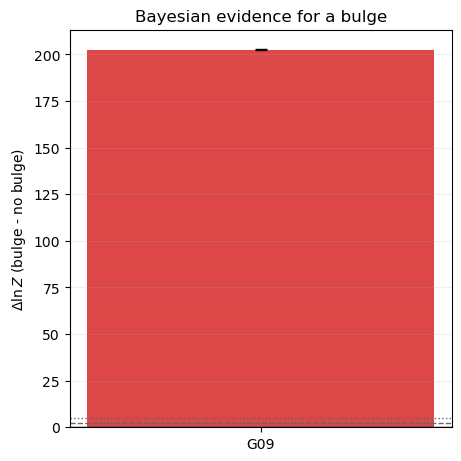

saved evidence diagnostic: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/G09_uv/results/figures/evidence_bulge_comparison.pdf
no_bulge: best-fit reduced chi-square = 1.038
bulge: best-fit reduced chi-square = 1.037


model,parameter,p16,p50,p84
str8,str33,float64,float64,float64
no_bulge,log10_m_baryon,10.35332586721463,10.358468159265062,10.363312765155088
no_bulge,disk_scale_radius_kpc,0.30578343314377104,0.3105922472315134,0.3151293531571276
no_bulge,log10_m200,12.994893508720248,12.998024461966532,12.99950680342898
no_bulge,source_x_arcsec,-0.027058873271212064,-0.026258246407962805,-0.02539531920320616
no_bulge,source_y_arcsec,-0.06232970650561354,-0.06133622932506111,-0.060214533810200775
no_bulge,flux_normalization,0.6934466258904624,0.6973751904715229,0.7013754788328919
no_bulge,position_angle_deg,58.89448713962981,59.10154175788497,59.30284342770426
no_bulge,surface_brightness_scale_arcsec,0.1513463244808967,0.15201249641648273,0.15266820322999125
no_bulge,velocity_dispersion_center_kms,66.25046991722084,66.66492824315245,67.09921872326667


In [7]:
if set(RESULTS) == {'no_bulge', 'bulge'}:
    no_bulge = RESULTS['no_bulge']
    bulge = RESULTS['bulge']
    EVIDENCE_TABLE = Table(
        rows=[(
            no_bulge['logz'], bulge['logz'], bulge['logz'] - no_bulge['logz'],
            np.hypot(no_bulge['logzerr'], bulge['logzerr']),
        )],
        names=(
            'lnZ no bulge', 'lnZ bulge', 'Delta lnZ',
            'Delta lnZ numerical error',
        ),
    )
    for name in EVIDENCE_TABLE.colnames:
        EVIDENCE_TABLE[name].format = '.3f'
    display(EVIDENCE_TABLE)

    delta = float(EVIDENCE_TABLE['Delta lnZ'][0])
    error = float(EVIDENCE_TABLE['Delta lnZ numerical error'][0])
    color = 'tab:blue' if delta < 2.5 else 'tab:orange' if delta < 5.0 else 'tab:red'
    fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)
    ax.bar([0], [delta], yerr=[error], color=color, alpha=0.85, capsize=4)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(2.5, color='0.4', lw=1, ls='--')
    ax.axhline(5.0, color='0.4', lw=1, ls=':')
    ax.set_xticks([0], ['G09'])
    ax.set_ylabel(r'$\Delta\ln Z$ (bulge - no bulge)')
    ax.set_title('Bayesian evidence for a bulge')
    ax.grid(axis='y', alpha=0.2)
    evidence_path = FIGURE_DIR / 'evidence_bulge_comparison.pdf'
    fig.savefig(evidence_path, bbox_inches='tight')
    plt.show()
    print(f'saved evidence diagnostic: {evidence_path}')

posterior_rows = []
for model_name, result in RESULTS.items():
    for name, values in result['posterior'].items():
        posterior_rows.append((model_name, name, *values))
    best_model = model_visibilities(result['best_parameters'])
    residual = (OBSERVATION['data'] - best_model) / OBSERVATION['sigma']
    dof = 2 * residual.size - len(MODEL_FREE_NAMES[model_name])
    print(f'{model_name}: best-fit reduced chi-square = {np.sum(np.abs(residual)**2)/dof:.3f}')

    directory = FIGURE_DIR / model_name
    directory.mkdir(parents=True, exist_ok=True)
    # Absolute ln Z is large and positive; exponentiating it overflows.
    fig, _ = dyplot.runplot(result['results'], logplot=True)
    fig.savefig(directory / 'dynesty_runplot.pdf', bbox_inches='tight')
    plt.close(fig)
    fig, _ = dyplot.cornerplot(
        result['results'], labels=MODEL_FREE_NAMES[model_name], show_titles=True,
    )
    fig.savefig(directory / 'dynesty_cornerplot.pdf', bbox_inches='tight')
    plt.close(fig)

if posterior_rows:
    posterior_table = Table(
        rows=posterior_rows, names=('model', 'parameter', 'p16', 'p50', 'p84'),
    )
    posterior_table.write(OUTPUT_DIR / 'posterior_summary.csv', overwrite=True)
    display(posterior_table)

In [8]:
def dirty_cube(flat_visibilities):
    cube = np.empty((UV_DATA.nchan, *XX_IMAGE_ARCSEC.shape), dtype=float)
    for channel, output_slice in enumerate(OBSERVATION['slices']):
        selected = ~OBSERVATION['flag'][channel]
        weight = 1.0 / UV_DATA.sigma[channel, selected]**2
        cube[channel], _ = vis_to_image_finufft_type3(
            UV_DATA.uvw_lam[0, channel, selected],
            UV_DATA.uvw_lam[1, channel, selected],
            flat_visibilities[output_slice], weight,
            XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC,
            eps=float(data_cfg['finufft_tolerance']),
        )
    return cube

for model_index, (model_name, result) in enumerate(RESULTS.items()):
    directory = FIGURE_DIR / model_name
    best = result['best_parameters']
    best_curve = rotation_curve(best)
    rng = np.random.default_rng(3100 + model_index)
    posterior_indices = rng.choice(
        len(result['weights']), size=min(512, len(result['weights'])),
        replace=True, p=result['weights'] / np.sum(result['weights']),
    )
    total_curves = np.array([
        rotation_curve(complete_parameters(result['results'].samples[i], model_name))['total_kms']
        for i in posterior_indices
    ])
    low, median, high = np.percentile(total_curves, [16, 50, 84], axis=0)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.fill_between(RADIUS_KPC, low, high, alpha=0.25, label='total 16–84%')
    ax.plot(RADIUS_KPC, median, label='total median')
    for component, label in (
        ('disk_kms', 'disk best'), ('bulge_kms', 'bulge best'), ('halo_kms', 'halo best'),
    ):
        ax.plot(RADIUS_KPC, best_curve[component], ls='--', label=label)
    ax.set(xlabel='Radius [kpc]', ylabel='Circular velocity [km/s]', title=model_name)
    ax.legend(fontsize=8)
    fig.savefig(directory / 'rotation_curve.pdf', bbox_inches='tight')
    plt.close(fig)

    best_vis = model_visibilities(best)
    data_dirty = dirty_cube(OBSERVATION['data'])
    model_dirty = dirty_cube(best_vis)
    residual_dirty = data_dirty - model_dirty
    source = intrinsic_cube(best)
    dv = abs(np.median(np.diff(VELOCITY_CHANNELS_KMS)))
    maps = [
        np.sum(data_dirty, axis=0) * dv,
        np.sum(model_dirty, axis=0) * dv,
        np.sum(residual_dirty, axis=0) * dv,
        np.sum(source, axis=0) * dv,
    ]
    titles = ('Observed dirty moment-0', 'Model dirty moment-0', 'Residual', 'Intrinsic source')
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
    symmetric = np.nanmax(np.abs(maps[2]))
    for index, (ax, image, title) in enumerate(zip(axes, maps, titles)):
        kwargs = {'cmap': 'RdBu_r', 'vmin': -symmetric, 'vmax': symmetric} if index == 2 else {'cmap': 'inferno'}
        shown = ax.imshow(image, origin='lower', **kwargs)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(shown, ax=ax, fraction=0.046, pad=0.03)
    fig.savefig(directory / 'dirty_moment0_comparison.pdf', bbox_inches='tight')
    plt.close(fig)
    print(f'saved diagnostics: {directory}')

saved diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/G09_uv/results/figures/no_bulge
saved diagnostics: /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/G09_uv/results/figures/bulge


## Channel-by-channel best-fit diagnostics

実観測visibilityとmaximum-likelihood modelを同じuv sampling・natural weightでdirty image化する。
4列はobserved dirty map、best-fit model、dirty residual、intrinsic sourceである。
最初の3列はStage 4と同じ`cm.roma_r`とcolor limitsを使う。dirty RMSの再検証まではcontourとPeak S/Nを表示しない。
Dirty imageは検証用であり、fitと$\chi^2$評価は独立な複素visibility上で行う。


In [9]:
def dirty_noise_rms():
    """Natural-weight dirty imageのchannel別thermal RMSをvisibility sigmaから計算する。"""
    rms = np.empty(UV_DATA.nchan, dtype=float)
    for channel, output_slice in enumerate(OBSERVATION['slices']):
        sigma = OBSERVATION['sigma'][output_slice]
        weight = 1.0 / sigma**2
        rms[channel] = np.sqrt(np.sum((weight * sigma)**2)) / np.sum(weight)
    return rms


def save_channel_diagnostics():
    observed_dirty = dirty_cube(OBSERVATION['data'])
    noise_rms = dirty_noise_rms()
    image_extent = [
        XX_IMAGE_ARCSEC.min(), XX_IMAGE_ARCSEC.max(),
        YY_IMAGE_ARCSEC.min(), YY_IMAGE_ARCSEC.max(),
    ]
    source_extent = [
        XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(),
        YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max(),
    ]
    rows = []

    for model_name in ('no_bulge', 'bulge'):
        result = RESULTS[model_name]
        best = result['best_parameters']
        best_visibilities = model_visibilities(best)
        model_dirty = dirty_cube(best_visibilities)
        residual_dirty = observed_dirty - model_dirty
        residual_sigma = residual_dirty / noise_rms[:, None, None]
        source = intrinsic_cube(best)

        visibility_chi2 = float(np.sum(
            np.abs((OBSERVATION['data'] - best_visibilities) / OBSERVATION['sigma'])**2
        ))
        dof = 2 * OBSERVATION['data'].size - len(MODEL_FREE_NAMES[model_name])
        reduced_chi2 = visibility_chi2 / dof
        rows.append((model_name, visibility_chi2, dof, reduced_chi2))

        directory = FIGURE_DIR / model_name
        directory.mkdir(parents=True, exist_ok=True)
        n_channels = len(VELOCITY_CHANNELS_KMS)
        fig, axes = plt.subplots(
            n_channels, 4, figsize=(8.5, 1.65 * n_channels), squeeze=False,
        )
        fig.subplots_adjust(wspace=0.02, hspace=0.02, top=0.975)
        image_vmin = -2.0 * float(np.median(noise_rms))
        image_vmax = 0.9 * max(
            float(np.nanmax(observed_dirty)), float(np.nanmax(model_dirty)),
        )
        source_vmax = float(np.nanmax(source))

        for channel, velocity_kms in enumerate(VELOCITY_CHANNELS_KMS):
            panels = (
                (observed_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                (model_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                (residual_dirty[channel], cm.roma_r, image_vmin, image_vmax, image_extent),
                (source[channel], cm.roma_r, 0.0, source_vmax, source_extent),
            )
            for column, (panel, cmap, vmin, vmax, extent) in enumerate(panels):
                axes[channel, column].imshow(
                    panel, origin='lower', extent=extent,
                    cmap=cmap, vmin=vmin, vmax=vmax,
                )
                axes[channel, column].set_xticks([])
                axes[channel, column].set_yticks([])
            axes[channel, 0].text(
                0.03, 0.93, f'{velocity_kms:+.0f} km/s',
                transform=axes[channel, 0].transAxes,
                color='white', fontsize=7, va='top',
            )

        titles = (
            'Observed dirty', 'Best-fit model dirty',
            'Residual dirty', 'Best-fit intrinsic source',
        )
        for axis_object, title in zip(axes[0], titles, strict=True):
            axis_object.set_title(title, fontsize=9)
        fig.suptitle(
            f'G09 — {model_name}; visibility reduced $\\chi^2$={reduced_chi2:.3f}',
            fontsize=10, y=0.995,
        )
        output_path = directory / 'all_channel_dirty_comparison.pdf'
        fig.savefig(output_path, bbox_inches='tight', pad_inches=0.03)
        plt.close(fig)
        print(f'saved {output_path.relative_to(WORKFLOW_DIR)}')

    diagnostics = Table(
        rows=rows,
        names=('model', 'visibility_chi2', 'dof', 'reduced_chi2'),
    )
    for name in diagnostics.colnames[1:]:
        diagnostics[name].format = '.5g'
    diagnostics_path = OUTPUT_DIR / 'fit_diagnostics.csv'
    diagnostics.write(diagnostics_path, format='ascii.csv', overwrite=True)
    display(diagnostics)
    print(f'saved {diagnostics_path.relative_to(WORKFLOW_DIR)}')
    return diagnostics


if set(RESULTS) == {'no_bulge', 'bulge'}:
    FIT_DIAGNOSTICS = save_channel_diagnostics()
else:
    print('channel diagnostics skipped: both model results are required')


saved output/G09_uv/results/figures/no_bulge/all_channel_dirty_comparison.pdf
saved output/G09_uv/results/figures/bulge/all_channel_dirty_comparison.pdf


model,visibility_chi2,dof,reduced_chi2
str8,float64,int64,float64
no_bulge,5.0402e+05,4.8553e+05,1.0381
bulge,5.0364e+05,4.8552e+05,1.0373


saved output/G09_uv/results/fit_diagnostics.csv


## Bulge/no-bulge rotation-curve comparison

Maximum-likelihood sampleをbest-fit線として表示し、joint weighted posteriorを回転曲線へ伝播した
16–84 percentileを帯で示す。G09には既知のtruthがないため、2つのmass modelを直接比較する。


In [10]:
ROTATION_COMPONENTS = ('total', 'disk', 'bulge', 'halo')


def posterior_rotation_curve_intervals(model_name, max_samples=2000):
    result = RESULTS[model_name]
    samples = np.asarray(result['results'].samples)
    weights = np.asarray(result['weights'], dtype=float)
    weights /= weights.sum()
    sample_count = min(max_samples, samples.shape[0])
    rng = np.random.default_rng(104729 + (0 if model_name == 'no_bulge' else 1))
    indices = rng.choice(
        samples.shape[0], size=sample_count, replace=True, p=weights,
    )
    curves = {
        component: np.empty((sample_count, RADIUS_KPC.size), dtype=float)
        for component in ROTATION_COMPONENTS
    }
    for row, sample_index in enumerate(indices):
        parameters = complete_parameters(samples[sample_index], model_name)
        curve = rotation_curve(parameters)
        for component in ROTATION_COMPONENTS:
            curves[component][row] = curve[f'{component}_kms']
    return {
        component: np.percentile(values, (16.0, 50.0, 84.0), axis=0)
        for component, values in curves.items()
    }


if set(RESULTS) == {'no_bulge', 'bulge'}:
    ROTATION_INTERVALS = {
        model_name: posterior_rotation_curve_intervals(model_name)
        for model_name in ('no_bulge', 'bulge')
    }
    styles = {
        'no_bulge': dict(color='tab:blue', lw=2.2, ls='--', label='no-bulge ML fit'),
        'bulge': dict(color='tab:red', lw=1.8, ls='-.', label='bulge ML fit'),
    }
    fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
    for model_name in ('no_bulge', 'bulge'):
        lower, _, upper = ROTATION_INTERVALS[model_name]['total']
        color = styles[model_name]['color']
        ax.fill_between(
            RADIUS_KPC, lower, upper, color=color, alpha=0.18, linewidth=0,
        )
        best = rotation_curve(RESULTS[model_name]['best_parameters'])
        ax.plot(RADIUS_KPC, best['total_kms'], **styles[model_name])
    ax.set_xlabel('Radius [kpc]')
    ax.set_ylabel('Circular velocity [km/s]')
    ax.set_title('G09 total rotation curve')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    total_path = FIGURE_DIR / 'rotation_curves_total_comparison.pdf'
    fig.savefig(total_path, bbox_inches='tight')
    plt.close(fig)
    print(f'saved {total_path.relative_to(WORKFLOW_DIR)}')

    component_colors = {
        'total': 'black', 'disk': 'tab:blue',
        'bulge': 'tab:orange', 'halo': 'tab:green',
    }
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 4.5), sharex=True, sharey=True,
        squeeze=False, constrained_layout=True,
    )
    for column, model_name in enumerate(('no_bulge', 'bulge')):
        ax = axes[0, column]
        best_curve = rotation_curve(RESULTS[model_name]['best_parameters'])
        intervals = ROTATION_INTERVALS[model_name]
        for component, color in component_colors.items():
            key = f'{component}_kms'
            lower, _, upper = intervals[component]
            ax.fill_between(
                RADIUS_KPC, lower, upper, color=color, alpha=0.12, linewidth=0,
            )
            ax.plot(
                RADIUS_KPC, best_curve[key], color=color, lw=1.8,
                label=component,
            )
        ax.set_title(model_name.replace('_', '-'))
        ax.set_xlabel('Radius [kpc]')
        ax.grid(alpha=0.2)
    axes[0, 0].set_ylabel('Circular velocity [km/s]')
    axes[0, 0].legend(loc='upper right', ncol=2, fontsize=8, frameon=False)
    fig.suptitle('Lines: maximum likelihood; shaded: posterior 16–84%', fontsize=11)
    component_path = FIGURE_DIR / 'rotation_curves_components_comparison.pdf'
    fig.savefig(component_path, bbox_inches='tight')
    plt.close(fig)
    print(f'saved {component_path.relative_to(WORKFLOW_DIR)}')
else:
    print('rotation diagnostics skipped: both model results are required')


saved output/G09_uv/results/figures/rotation_curves_total_comparison.pdf
saved output/G09_uv/results/figures/rotation_curves_components_comparison.pdf


## Interpretation checklist

- best-fit reduced χ² が大きい場合、prior を広げる前に channel order、phase center、uv sign、Jy/pixel 規格化、`statwt`、short-baseline cut を確認する。
- `B/T=0` が bulge prior の境界に含まれるため、ΔlnZ と同時に `B/T` posterior の zero 近傍、residual、rotation-curve component を見る。
- inclination–mass、source size–magnification、B/T–bulge radius、halo–baryon、external convergence の縮退を corner plot で確認する。
- 現在の lens center `(0.217, 0.290) arcsec` は HST Gaussian centroid に固定している。astrometric registration を更新した場合は TOML と cache version を更新する。
- dirty moment-0 は可視化用であり、fit statistic は常に複素 visibility から計算される。